<a href="https://colab.research.google.com/github/athishk13/FaceDetection/blob/main/FULL_PROJECT_face_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow

In [ ]:
pip install labelme opencv-python matplotlib albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 46.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.8/270.8 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.1 MB/s eta 0:00:00
  Created wheel for labelme: filename=labelme-5.6.0-py3-none-any.whl size=1439635 sha256=0af68b4e82

In [ ]:
import os
import time
import uuid
import cv2

In [ ]:
os.makedirs("data", exist_ok=True)
os.makedirs("data/images", exist_ok=True)
os.makedirs("data/labels", exist_ok=True)

In [ ]:
IMAGES_PATH = os.path.join('data','images')
number_images = 30

In [ ]:
'''
cap = cv2.VideoCapture(1)
for imgnum in range(number_images):
    print('Collecting image {}'.format(imgnum))
    ret, frame = cap.read()
    imgname = os.path.join(IMAGES_PATH,f'{str(uuid.uuid1())}.jpg')
    cv2.imwrite(imgname, frame)
    cv2.imshow('frame', frame)
    time.sleep(0.5)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()
cv2.waitKey(1)

#capturing images
'''

"\ncap = cv2.VideoCapture(1)\nfor imgnum in range(number_images):\n    print('Collecting image {}'.format(imgnum))\n    ret, frame = cap.read()\n    imgname = os.path.join(IMAGES_PATH,f'{str(uuid.uuid1())}.jpg')\n    cv2.imwrite(imgname, frame)\n    cv2.imshow('frame', frame)\n    time.sleep(0.5)\n\n    if cv2.waitKey(1) & 0xFF == ord('q'):\n        break\ncap.release()\ncv2.destroyAllWindows()\ncv2.waitKey(1)\n\n#capturing images\n"

In [ ]:
#!labelme
#creating labels and outputting to label file

In [ ]:
import tensorflow as tf
import cv2
import json
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [ ]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
images = tf.data.Dataset.list_files('data/images/*.jpg')

In [ ]:
images.as_numpy_iterator().next()

b'data/images/bf2a6ce4-cd7e-11ef-908a-c69179c61f74.jpg'

In [ ]:
def load_image(x):
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_jpeg(byte_img)
    return img
#reading images

In [ ]:
images = images.map(load_image)

In [ ]:
images.as_numpy_iterator().next()

array([[[119, 125, 141],
        [120, 126, 140],
        [123, 126, 141],
        ...,
        [160, 122,  83],
        [160, 122,  83],
        [160, 122,  83]],

       [[119, 125, 141],
        [120, 126, 140],
        [123, 126, 141],
        ...,
        [160, 122,  83],
        [160, 122,  83],
        [160, 122,  83]],

       [[119, 125, 141],
        [120, 126, 140],
        [124, 127, 142],
        ...,
        [160, 122,  83],
        [160, 122,  83],
        [160, 122,  83]],

       ...,

       [[225, 184, 122],
        [225, 184, 122],
        [224, 183, 121],
        ...,
        [136, 131, 111],
        [135, 130, 110],
        [135, 130, 110]],

       [[227, 183, 122],
        [227, 183, 122],
        [224, 183, 121],
        ...,
        [137, 132, 113],
        [137, 132, 113],
        [137, 132, 113]],

       [[227, 183, 122],
        [227, 183, 122],
        [224, 183, 121],
        ...,
        [139, 134, 115],
        [138, 133, 114],
        [138, 133, 114]]

In [ ]:
type(images)

tensorflow.python.data.ops.map_op._MapDataset

In [ ]:
image_generator = images.batch(4).as_numpy_iterator()

In [ ]:
plot_images = image_generator.next()

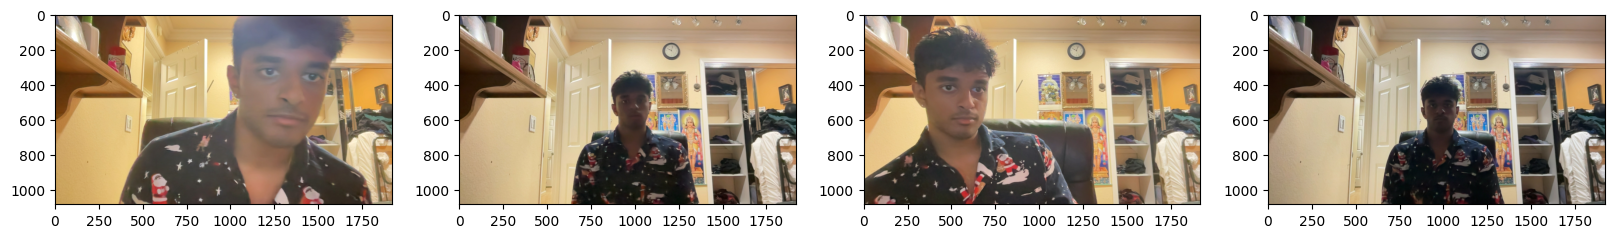

In [ ]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, image in enumerate(plot_images):
    ax[idx].imshow(image)
plt.show()
#displaying images

In [ ]:
from sklearn.model_selection import train_test_split
import os
import glob
import shutil

In [ ]:
image_paths = glob.glob("data/images/*.jpg")

In [ ]:
train_paths, test_paths = train_test_split(
    image_paths,
    test_size=0.2,
    random_state=42
)

train_paths, val_paths = train_test_split(
    train_paths,
    test_size=0.25,
    random_state=42
)

print(f"Train: {len(train_paths)} images")
print(f"Validation: {len(val_paths)} images")
print(f"Test: {len(test_paths)} images")

#splitting data

Train: 54 images
Validation: 18 images
Test: 18 images


In [ ]:
os.makedirs("data/train/images", exist_ok=True)
os.makedirs("data/val/images", exist_ok=True)
os.makedirs("data/test/images", exist_ok=True)
os.makedirs("data/train/labels", exist_ok=True)
os.makedirs("data/val/labels", exist_ok=True)
os.makedirs("data/test/labels", exist_ok=True)

In [ ]:
for path in train_paths:
    filename = os.path.basename(path)
    shutil.copy(path, os.path.join("data/train/images", filename))


for path in val_paths:
    filename = os.path.basename(path)
    shutil.copy(path, os.path.join("data/val/images", filename))


for path in test_paths:
    filename = os.path.basename(path)
    shutil.copy(path, os.path.join("data/test/images", filename))


In [ ]:
for folder in ['train', 'test', 'val']:
    for file in os.listdir(os.path.join('data', folder, 'images')):
        filename = file.split('.')[0]+'.json'
        existing_filepath = os.path.join('data', 'labels', filename)
        if os.path.exists(existing_filepath):
            new_filepath = os.path.join('data', folder, 'labels', filename)
            os.replace(existing_filepath, new_filepath)
#attaching the according labels to the train, test, and val iamge data


In [ ]:
import albumentations as ab

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.0 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
#augmenting functions
augmentor = ab.Compose([ab.RandomCrop(width=850,height=850),
                         ab.HorizontalFlip(p=0.5),
                         ab.RandomBrightnessContrast(p=0.2),
                         ab.RandomGamma(p=0.2),
                         ab.RGBShift(p=0.2),
                         ab.VerticalFlip(p=0.5)],
                        bbox_params=ab.BboxParams(format='albumentations', label_fields=['class_labels']))

In [ ]:
img = cv2.imread(os.path.join('data','train','images', 'a7c5092e-cd7e-11ef-908a-c69179c61f74.jpg'))
img.shape

(1080, 1920, 3)

In [ ]:
with open(os.path.join('data','train','labels', 'a7c5092e-cd7e-11ef-908a-c69179c61f74.json'), 'r') as f:
    label = json.load(f)

In [ ]:
label['shapes'][0]['points']

[[1049.9999999999998, 340.7692307692307],
 [1425.3846153846152, 793.0769230769231]]

In [ ]:
coords = [0,0,0,0]
coords[0] = label['shapes'][0]['points'][0][0]
coords[1] = label['shapes'][0]['points'][0][1]
coords[2] = label['shapes'][0]['points'][1][0]
coords[3] = label['shapes'][0]['points'][1][1]

#creatinng coords for the label (box around head)

In [ ]:
coords

[1049.9999999999998, 340.7692307692307, 1425.3846153846152, 793.0769230769231]

In [ ]:
coords = list(np.divide(coords, [1920, 1080, 1920, 1080]))
#normalizing coords

In [ ]:
coords

[0.5468749999999999,
 0.3155270655270655,
 0.7423878205128205,
 0.7343304843304843]

In [ ]:
augmented = augmentor(image=img, bboxes=[coords], class_labels=['face'])
#augmented image

In [ ]:
augmented

{'image': array([[[165, 198, 217],
         [157, 192, 212],
         [136, 170, 194],
         ...,
         [ 42,  46,  65],
         [ 42,  46,  65],
         [ 42,  46,  65]],
 
        [[196, 229, 244],
         [185, 218, 237],
         [156, 190, 213],
         ...,
         [ 41,  45,  64],
         [ 41,  45,  64],
         [ 42,  46,  65]],
 
        [[213, 245, 255],
         [200, 234, 250],
         [175, 210, 230],
         ...,
         [ 39,  45,  64],
         [ 39,  45,  64],
         [ 39,  45,  64]],
 
        ...,
 
        [[ 17,  20,  34],
         [ 14,  19,  34],
         [ 15,  20,  35],
         ...,
         [142, 196, 226],
         [142, 196, 226],
         [142, 196, 226]],
 
        [[ 15,  18,  32],
         [ 15,  18,  32],
         [ 18,  21,  36],
         ...,
         [142, 196, 226],
         [142, 196, 226],
         [142, 196, 226]],
 
        [[ 16,  19,  33],
         [ 19,  22,  36],
         [ 22,  25,  40],
         ...,
         [142, 196,

In [ ]:
augmented['bboxes']

[[0.0, 0.15384613626143512, 0.18470588235294116, 0.6859728392432718]]

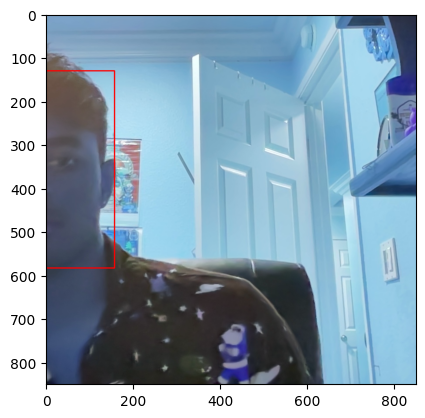

In [ ]:
cv2.rectangle(augmented['image'],
              tuple(np.multiply(augmented['bboxes'][0][:2], [850,850]).astype(int)),
              tuple(np.multiply(augmented['bboxes'][0][2:], [850,850]).astype(int)),
                  (255,0,0), 2)

plt.imshow(augmented['image'])

In [ ]:
os.makedirs("aug_data/train/images", exist_ok=True)
os.makedirs("aug_data/val/images", exist_ok=True)
os.makedirs("aug_data/test/images", exist_ok=True)
os.makedirs("aug_data/train/labels", exist_ok=True)
os.makedirs("aug_data/val/labels", exist_ok=True)
os.makedirs("aug_data/test/labels", exist_ok=True)

In [ ]:
for partition in ['train', 'test' ,'val']:
    for image in os.listdir(os.path.join('data', partition, 'images')):
        img = cv2.imread(os.path.join('data', partition, 'images', image))
        coords = [0,0,0.00001,0.00001]
        label_path = os.path.join('data', partition, 'labels', f'{image.split(".")[0]}.json')
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                label = json.load(f)
            coords[0] = label['shapes'][0]['points'][0][0]
            coords[1] = label['shapes'][0]['points'][0][1]
            coords[2] = label['shapes'][0]['points'][1][0]
            coords[3] = label['shapes'][0]['points'][1][1]
            coords = list(np.divide(coords, [1920, 1080, 1920, 1080]))

        try:
            for x in range(60):
                augmented = augmentor(image=img, bboxes=[coords], class_labels=['face'])
                cv2.imwrite(os.path.join('aug_data', partition, 'images', f'{image.split(".")[0]}.{x}.jpg'), augmented['image'])
                annotation = {}
                annotation['image'] = image

                if os.path.exists(label_path):
                    if len(augmented['bboxes']) == 0:
                        annotation['bbox'] = [0,0,0,0]
                        annotation['class'] = 0
                    else:
                        annotation['bbox'] = augmented['bboxes'][0]
                        annotation['class'] = 1
                else:
                    annotation['bbox'] = [0,0,0,0]
                    annotation['class'] = 0

                with open(os.path.join('aug_data', partition, 'labels', f'{image.split(".")[0]}.{x}.json'), 'w') as f:
                    json.dump(annotation, f)
        except Exception as e:
            print(e)

#augmenting all images then splitting into train test val within augmented data folder

/usr/local/lib/python3.10/dist-packages/albumentations/core/bbox_utils.py:478: RuntimeWarning: invalid value encountered in divide
  & (clipped_box_areas / denormalized_box_areas >= min_visibility - epsilon)


In [ ]:
train_images = tf.data.Dataset.list_files('aug_data/train/images/*.jpg', shuffle=False)
train_images = train_images.map(load_image)
train_images = train_images.map(lambda x: tf.image.resize(x, (120,120)))
train_images = train_images.map(lambda x: x/255)

In [ ]:
test_images = tf.data.Dataset.list_files('aug_data/test/images/*.jpg', shuffle=False)
test_images = test_images.map(load_image)
test_images = test_images.map(lambda x: tf.image.resize(x, (120,120)))
test_images = test_images.map(lambda x: x/255)

In [ ]:
val_images = tf.data.Dataset.list_files('aug_data/val/images/*.jpg', shuffle=False)
val_images = val_images.map(load_image)
val_images = val_images.map(lambda x: tf.image.resize(x, (120,120)))
val_images = val_images.map(lambda x: x/255)

In [ ]:
train_images.as_numpy_iterator().next()

array([[[0.43219635, 0.42043164, 0.38513753],
        [0.3990196 , 0.3872549 , 0.35980392],
        [0.2910131 , 0.2901961 , 0.26127452],
        ...,
        [0.5167008 , 0.40800652, 0.36156717],
        [0.498509  , 0.38903186, 0.33396652],
        [0.48218957, 0.3727124 , 0.3254902 ]],

       [[0.38698936, 0.37522465, 0.34777367],
        [0.39417893, 0.38241422, 0.35496324],
        [0.2901961 , 0.28937906, 0.26045755],
        ...,
        [0.50696504, 0.40745506, 0.35565776],
        [0.5019608 , 0.4       , 0.34901962],
        [0.4862745 , 0.38039216, 0.3372549 ]],

       [[0.2903595 , 0.2849333 , 0.26486927],
        [0.414808  , 0.38735703, 0.35598448],
        [0.29803923, 0.29722223, 0.26830068],
        ...,
        [0.5058824 , 0.40392157, 0.34543842],
        [0.4919935 , 0.39003268, 0.3390523 ],
        [0.48235294, 0.3882353 , 0.34117648]],

       ...,

       [[0.681502  , 0.58901817, 0.4886912 ],
        [0.67761445, 0.58513063, 0.48480368],
        [0.6798951 , 0

In [ ]:
def load_labels(label_path):
    with open(label_path.numpy(), 'r', encoding = 'utf-8') as f:
        label = json.load(f)
    return [label['class']], label['bbox']
    #running load labels function over every value (json object in dataset)


In [ ]:
train_labels = tf.data.Dataset.list_files('aug_data/train/labels/*.json', shuffle=False)
train_labels = train_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.uint8, tf.float16]))

In [ ]:
test_labels = tf.data.Dataset.list_files('aug_data/test/labels/*.json', shuffle=False)
test_labels = test_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.uint8, tf.float16]))

In [ ]:
val_labels = tf.data.Dataset.list_files('aug_data/val/labels/*.json', shuffle=False)
val_labels = val_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.uint8, tf.float16]))

In [ ]:
train_labels.as_numpy_iterator().next()
#gives us the class (whether face exists or no), and the set of coordinates of where the face exists

(array([1], dtype=uint8),
 array([0.7   , 0.1957, 1.    , 0.722 ], dtype=float16))

In [ ]:
#counting number of data in each perspective file
len(train_images), len(train_labels), len(test_images), len(test_labels), len(val_images), len(val_labels)

(3240, 3240, 1080, 1080, 1080, 1080)

In [ ]:
#combining label and image samples
train = tf.data.Dataset.zip((train_images, train_labels))
train = train.shuffle(5000)
train = train.batch(8)
train = train.prefetch(4)

In [ ]:
test = tf.data.Dataset.zip((test_images, test_labels))
test = test.shuffle(1500)
test = test.batch(8)
test = test.prefetch(4)

In [ ]:
val = tf.data.Dataset.zip((val_images, val_labels))
val = val.shuffle(1500)
val = val.batch(8)
val = val.prefetch(4)

In [ ]:
train.as_numpy_iterator().next()[1]

(array([[1],
        [0],
        [1],
        [0],
        [1],
        [0],
        [0],
        [1]], dtype=uint8),
 array([[0.8003, 0.1772, 1.    , 0.521 ],
        [0.    , 0.    , 0.    , 0.    ],
        [0.4377, 0.125 , 0.9985, 0.8926],
        [0.    , 0.    , 0.    , 0.    ],
        [0.9565, 0.2632, 1.    , 0.768 ],
        [0.    , 0.    , 0.    , 0.    ],
        [0.    , 0.    , 0.    , 0.    ],
        [0.2122, 0.4336, 0.442 , 0.7104]], dtype=float16))

In [ ]:
data_samples = train.as_numpy_iterator()

In [ ]:
res = data_samples.next()

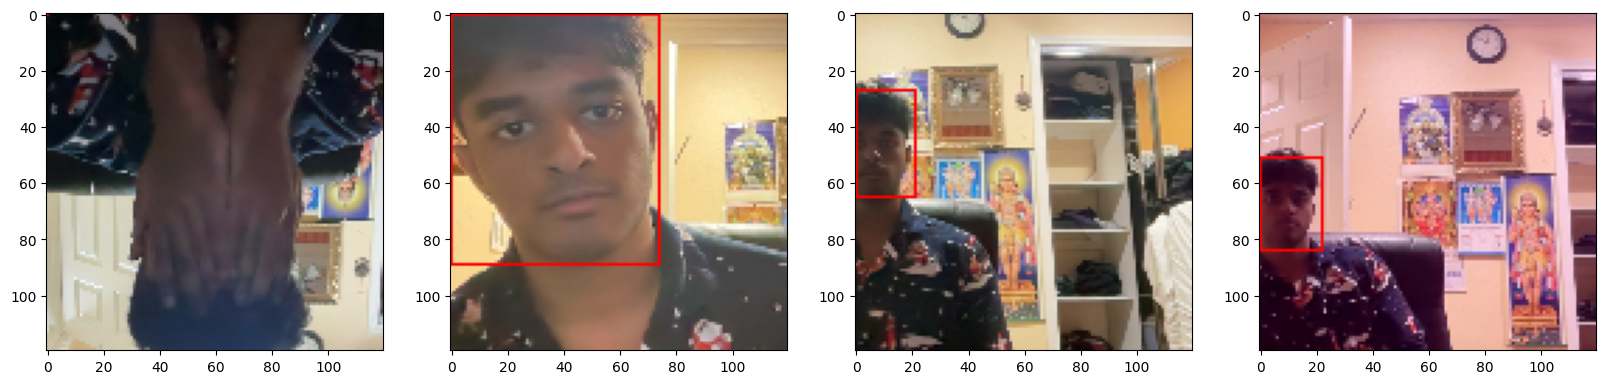

In [ ]:
fig, ax = plt.subplots(ncols=4, figsize=(20, 20))

for idx in range(4):
    # Extract the sample image and coordinates
    sample_image = res[0][idx].numpy() if isinstance(res[0], tf.Tensor) else res[0][idx]
    sample_coords = res[1][1][idx].numpy() if isinstance(res[1][1], tf.Tensor) else res[1][1][idx]

    # Make a writable copy of the image
    sample_image = sample_image.copy()

    # Ensure the image is in uint8 format
    if sample_image.dtype != np.uint8:
        #adjust to normalization
        sample_image = (sample_image * 255).astype(np.uint8)

    # Calculate coordinates
    # Assuming sample_coords are normalized between 0 and 1
    scale = [120, 120]  # Replace with actual image dimensions if different
    top_left = tuple((sample_coords[:2] * scale).astype(int))
    bottom_right = tuple((sample_coords[2:] * scale).astype(int))

    # Draw the rectangle
    cv2.rectangle(sample_image, top_left, bottom_right, (255, 0, 0), 1)

    # Display the image
    ax[idx].imshow(sample_image)

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, Dense, GlobalMaxPooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers.legacy import Adam

In [ ]:
vgg = VGG16(include_top=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, None, None, 3)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, None, None, 64)      │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, None, None, 64)      │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, None, None, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, None, None, 128)     │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, None, None, 128)     │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, None, None, 128)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, None, None, 256)     │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, None, None, 256)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, None, None, 512)     │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, None, None, 512)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, None, None, 512)     │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#neural network building
def build_model():
    input_layer = Input(shape=(120,120,3))
    vgg = VGG16(include_top=False)(input_layer)

    #classification model
    f1 = GlobalMaxPooling2D(name='global_max_classification')(vgg)
    class1 = Dense(2048, activation='relu', name='classification_dense')(f1)
    class2 = Dense(1, activation='sigmoid', name='classification_output')(class1)

    #bounding box model
    f2 = GlobalMaxPooling2D(name='global_max_regression')(vgg)
    regress1 = Dense(2048, activation='relu', name='regression_dense')(f2)
    regress2 = Dense(4, activation='sigmoid', name='regression_output')(regress1)

    facetracker = Model(inputs=input_layer, outputs=[class2, regress2])
    return facetracker

#idea of neural networks: focus on the input and getting to the output,
#and tweak the middle layers to work to your advantage

In [ ]:
facetracker = build_model()

In [ ]:
facetracker.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 120, 120, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ vgg16 (Functional)        │ (None, 3, 3, 512)      │     14,714,688 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_classification │ (None, 512)            │              0 │ vgg16[0][0]            │
│ (GlobalMaxPooling2D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_regression     │ (None, 512)            │              0 │ vgg16[0][0]            │
│ (GlobalMaxPooling2D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ classification_dense      │ (None, 2048)           │      1,050,624 │ global_max_classifica… │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ regression_dense (Dense)  │ (None, 2048)           │      1,050,624 │ global_max_regression… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ classification_output     │ (None, 1)              │          2,049 │ classification_dense[… │
│ (Dense)                   │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ regression_output (Dense) │ (None, 4)              │          8,196 │ regression_dense[0][0] │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 16,826,181 (64.19 MB)

 Trainable params: 16,826,181 (64.19 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
X, y = train.as_numpy_iterator().next()

In [ ]:
X.shape

(8, 120, 120, 3)

In [ ]:
y[0].shape

(8, 1)

In [ ]:
classes, coords = facetracker.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [ ]:
classes, coords
#predictions not yet strong since no training

(array([[0.53836966],
        [0.48370892],
        [0.4992747 ],
        [0.6147522 ],
        [0.5641222 ],
        [0.5132598 ],
        [0.59906405],
        [0.5908623 ]], dtype=float32),
 array([[0.39492595, 0.5511198 , 0.61935717, 0.63794917],
        [0.42083508, 0.590779  , 0.59465927, 0.58924055],
        [0.4182321 , 0.5820071 , 0.5845063 , 0.6966235 ],
        [0.4538827 , 0.54377943, 0.5899859 , 0.5979302 ],
        [0.41471723, 0.5569833 , 0.5336915 , 0.64778954],
        [0.55828476, 0.52017885, 0.55970615, 0.59140885],
        [0.40534878, 0.5853999 , 0.64517033, 0.6556738 ],
        [0.34851313, 0.59333265, 0.6026806 , 0.5971585 ]], dtype=float32))

In [ ]:
len(train)

405

In [ ]:
batches_per_epoch = len(train)
lr_decay = (1/0.75 - 1)/batches_per_epoch

In [ ]:
lr_decay

0.0008230452674897117

In [ ]:
opt = tf.keras.optimizers.Adam(learning_rate=0.0001)
#defining optimizer (keras Adam)

In [ ]:
def localization_loss(y_true, y_pred):
    delta_coord = tf.reduce_sum(tf.square(y_true[:,:2] - y_pred[:,:2]))
    h_true = y_true[:,3] - y_true[:,1]
    w_true = y_true[:,2] - y_true[:,0]

    h_pred = y_pred[:,3] - y_pred[:,1]
    w_pred = y_pred[:,2] - y_pred[:,0]

    delta_size = tf.reduce_sum(tf.square(w_true - w_pred) + tf.square(h_true - h_pred))

    return delta_coord + delta_size

#localization loss calculation difference between true value and predicted value)

In [ ]:
classloss = tf.keras.losses.BinaryCrossentropy()
regressloss = localization_loss

In [ ]:
localization_loss(y[1], coords).numpy()

2.216568

In [ ]:
classloss(y[0], classes).numpy()

0.63281775

In [ ]:
regressloss(y[1], coords).numpy()

2.216568

In [ ]:
#training pipeline
class FaceTracker(Model):
    def __init__(self, facetracker, **kwargs):
        super().__init__(**kwargs)
        self.model = facetracker

    def compile(self, opt, classloss, localizationloss, **kwargs):
        super().compile(**kwargs)
        self.class_loss_fn = classloss
        self.loc_loss_fn = localizationloss
        self.opt = opt

    def train_step(self, batch, **kwargs): #taking in batch of data and training per batch
        X, (class_labels, bbox_labels) = batch #separating into X and y values


        with tf.GradientTape() as tape: #calculate each operation happening in our NN
            classes, coords = self.model(X, training=True) #make prediction with facetracker model and passing through our X values (preprocessed images)

            class_labels = tf.reshape(class_labels, (8, 1))

            batch_classloss = self.class_loss_fn(class_labels, classes) #y[0] is  y_true /// classes is y_pred
            batch_regressloss = self.loc_loss_fn(tf.cast(bbox_labels, tf.float32), coords) #y[1] is y_true (casted) /// coords is y_pred
            total_loss = batch_regressloss + 0.5*batch_classloss

            grad = tape.gradient(total_loss, self.model.trainable_variables) #receives each one of the calculations from the operations in NN
            #^^passes total_loss to calculate with respect to loss function^^
            #gradients: optimization algorithm to minimize cost of a function **essentially to find best possible solution**
            self.opt.apply_gradients(zip(grad, self.model.trainable_variables))
            #^^loops through each gradient and apply gradient descent^^
            #^^should be optimizing towards minimizing that loss^^


            return {"total_loss": total_loss, "class_loss":batch_classloss, "regress_loss":batch_regressloss}
            #returning those losses, gets dictionary and when running training_step, we can see progress of model

    def test_step(self, batch, **kwargs):
        X, (class_labels, bbox_labels) = batch

        class_labels = tf.reshape(class_labels, (8, 1))

        classes, coords = self.model(X, training=False)
        #doesn't calculate **backpropagation**
        batch_classloss = self.class_loss_fn(class_labels, classes)
        batch_regressloss = self.loc_loss_fn(tf.cast(bbox_labels, tf.float32), coords)
        total_loss = batch_regressloss + 0.5*batch_classloss

        #no necessity of calculating gradients, since no need to update parameters of testing
        return {"total_loss":total_loss, "class_loss":batch_classloss, "regress_loss":batch_regressloss}

    def call(self, X, **kwargs):
        return self.model(X, **kwargs)
    #^^for .predict function call^^

In [ ]:
model = FaceTracker(facetracker)
#passing our neural network to our training model
#facetracker model maps into this model for our custom training step

In [ ]:
model.compile(opt, classloss, regressloss) #pass into compiler
#configures model for two-part training
#one part is to account for classification loss to fix predictive accuracy
#another part to account for regression(localization) loss to fix accuracy on that part

In [ ]:
logdir = 'logs'
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [ ]:
hist = model.fit(train, epochs=10, validation_data = val, callbacks=[tensorboard_callback])

Epoch 1/10
405/405 ━━━━━━━━━━━━━━━━━━━━ 63s 86ms/step - class_loss: 0.2557 - regress_loss: 0.7300 - total_loss: 0.8578 - val_class_loss: 0.3638 - val_regress_loss: 0.8511 - val_total_loss: 1.0330
Epoch 2/10
405/405 ━━━━━━━━━━━━━━━━━━━━ 44s 82ms/step - class_loss: 0.0864 - regress_loss: 0.2219 - total_loss: 0.2651 - val_class_loss: 0.1550 - val_regress_loss: 0.8051 - val_total_loss: 0.8826
Epoch 3/10
405/405 ━━━━━━━━━━━━━━━━━━━━ 44s 80ms/step - class_loss: 0.0590 - regress_loss: 0.1332 - total_loss: 0.1626 - val_class_loss: 0.0060 - val_regress_loss: 0.0310 - val_total_loss: 0.0340
Epoch 4/10
405/405 ━━━━━━━━━━━━━━━━━━━━ 45s 82ms/step - class_loss: 0.0633 - regress_loss: 0.1303 - total_loss: 0.1620 - val_class_loss: 0.0154 - val_regress_loss: 0.0439 - val_total_loss: 0.0516
Epoch 5/10
405/405 ━━━━━━━━━━━━━━━━━━━━ 44s 79ms/step - class_loss: 0.0562 - regress_loss: 0.1467 - total_loss: 0.1748 - val_class_loss: 0.0062 - val_regress_loss: 0.0319 - val_total_loss: 0.0349
Epoch 6/10
405/405 ━

In [ ]:
hist.history

{'class_loss': [0.11858828365802765,
  0.0163617804646492,
  0.021056801080703735,
  0.02816750854253769,
  0.0058090100064873695,
  0.0028797967825084925,
  0.0033594216220080853,
  0.014999471604824066,
  0.0026938016526401043,
  0.004369068890810013],
 'regress_loss': [0.18985752761363983,
  0.301736056804657,
  0.054258618503808975,
  0.042977411299943924,
  0.023853089660406113,
  0.010630365461111069,
  0.0369720458984375,
  0.05164971947669983,
  0.036971770226955414,
  0.038121938705444336],
 'total_loss': [0.24915167689323425,
  0.3099169433116913,
  0.06478701531887054,
  0.05706116557121277,
  0.02675759419798851,
  0.012070263735949993,
  0.038651756942272186,
  0.05914945527911186,
  0.03831867128610611,
  0.04030647128820419],
 'val_class_loss': [0.363820344209671,
  0.1550234854221344,
  0.006009218282997608,
  0.01538880355656147,
  0.0061837490648031235,
  0.0035960571840405464,
  0.003686404787003994,
  0.0028888648375868797,
  0.045414168387651443,
  0.39607879519462

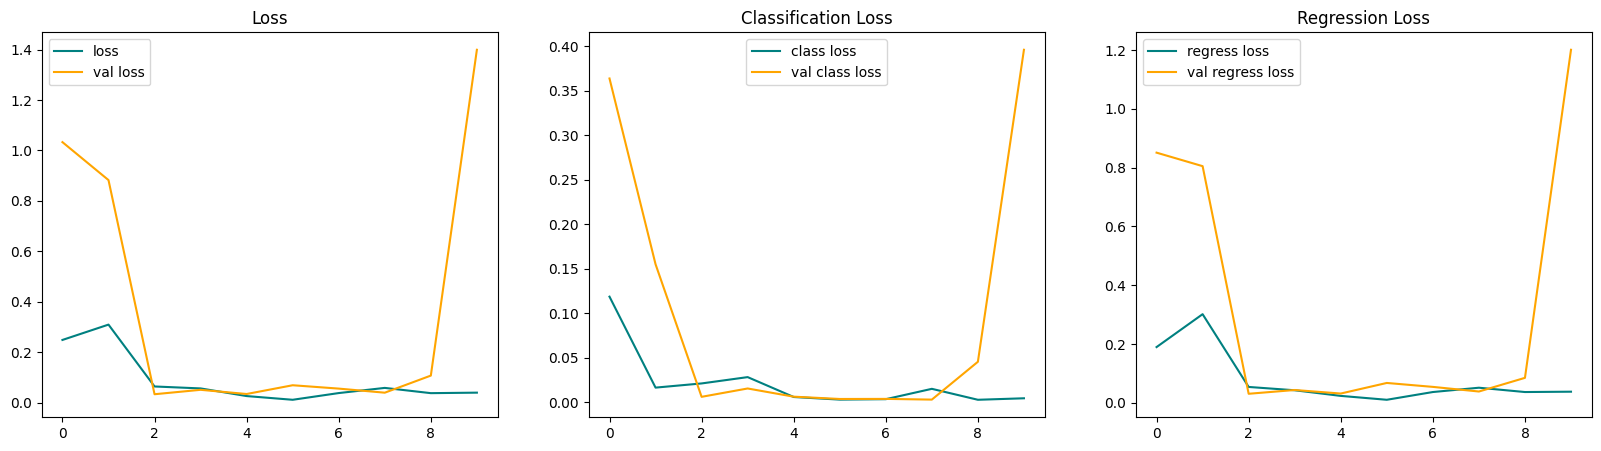

In [ ]:
fig, ax = plt.subplots(ncols=3, figsize=(20,5))

ax[0].plot(hist.history['total_loss'], color='teal', label='loss')
ax[0].plot(hist.history['val_total_loss'], color='orange', label='val loss')
ax[0].title.set_text('Loss')
ax[0].legend()

ax[1].plot(hist.history['class_loss'], color='teal', label='class loss')
ax[1].plot(hist.history['val_class_loss'], color='orange', label='val class loss')
ax[1].title.set_text('Classification Loss')
ax[1].legend()

ax[2].plot(hist.history['regress_loss'], color='teal', label='regress loss')
ax[2].plot(hist.history['val_regress_loss'], color='orange', label='val regress loss')
ax[2].title.set_text('Regression Loss')
ax[2].legend()

plt.show()

In [ ]:
test_data = test.as_numpy_iterator()

In [ ]:
test_sample = test_data.next()

In [ ]:
y_pred = facetracker.predict(test_sample[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


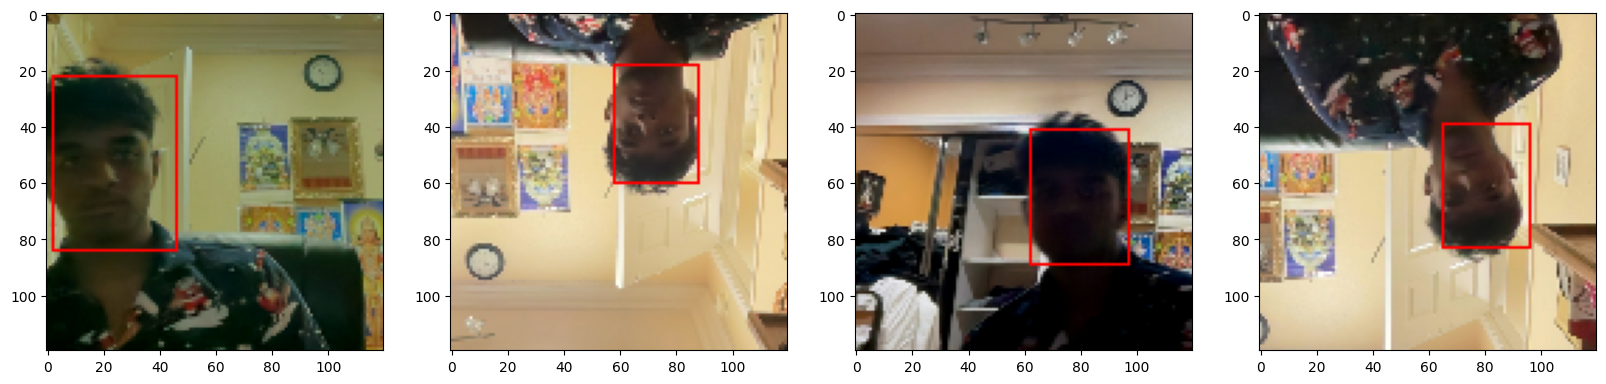

In [ ]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4):
    sample_image = test_sample[0][idx]
    sample_coords = y_pred[1][idx]
    sample_image = test_sample[0][idx].copy()

    if y_pred[0][idx] > 0.9:
        cv2.rectangle(sample_image,
                      tuple(np.multiply(sample_coords[:2], [120,120]).astype(int)),
                      tuple(np.multiply(sample_coords[2:], [120,120]).astype(int)),
                            (255,0,0), 1)

    ax[idx].imshow(sample_image)

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
facetracker.save('facetracker.h5')

In [ ]:
facetracker = load_model('facetracker.h5')

In [ ]:
cap = cv2.VideoCapture(1)
while cap.isOpened():
    _ , frame = cap.read()
    frame = frame[50:500, 50:500,:]

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    resized = tf.image.resize(rgb, (120,120))

    yhat = facetracker.predict(np.expand_dims(resized/255,0))
    sample_coords = yhat[1][0]

    if yhat[0] > 0.5:
        # Controls the main rectangle
        cv2.rectangle(frame,
                      tuple(np.multiply(sample_coords[:2], [450,450]).astype(int)),
                      tuple(np.multiply(sample_coords[2:], [450,450]).astype(int)),
                            (255,0,0), 2)
        # Controls the label rectangle
        cv2.rectangle(frame,
                      tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int),
                                    [0,-30])),
                      tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int),
                                    [80,0])),
                            (255,0,0), -1)

        # Controls the text rendered
        cv2.putText(frame, 'face', tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int),
                                               [0,-5])),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)

    cv2.imshow('EyeTrack', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js

def take_photo():
    js = Javascript('''
    async function takePhoto() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const canvas = document.createElement('canvas');
      const button = document.createElement('button');

      // Styles to help it look nice in the notebook
      div.style.textAlign = "center";
      button.textContent = "Capture";

      document.body.appendChild(div);
      div.appendChild(video);
      div.appendChild(document.createElement('br'));
      div.appendChild(button);

      // Get user permission and start video stream
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      // Capture the frame on button click
      let resolveClick;
      const clickPromise = new Promise((r) => resolveClick = r);
      button.onclick = () => resolveClick();
      await clickPromise;

      // Draw video frame to canvas
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      // Stop video
      video.srcObject.getTracks().forEach(t => t.stop());
      div.remove();

      // Return the base64 image string
      return canvas.toDataURL('image/png');
    }
    ''')
    display(js)
    data = eval_js('takePhoto()')
    return data


In [ ]:
import cv2
import numpy as np
import re
from base64 import b64decode

def js_to_image(js_reply):
    """
    Converts base64 image data to a numpy array
    """
    # js_reply is a base64 string like: data:image/png;base64,iVBORw0KGgoAAAANS...
    image_bytes = b64decode(js_reply.split(',')[1])
    nparr = np.frombuffer(image_bytes, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)
    return img


<IPython.core.display.Javascript object>

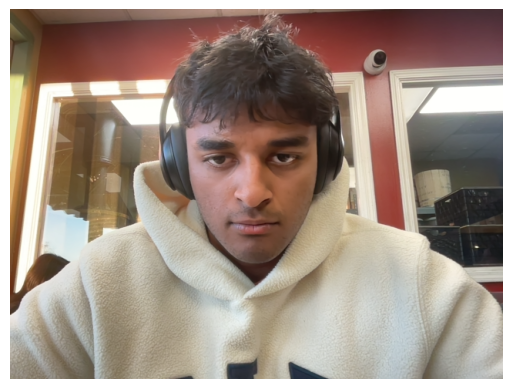

In [ ]:
# Take a photo from webcam (via JS)
snapshot_data = take_photo()
if snapshot_data:
    # Convert to OpenCV format
    frame = js_to_image(snapshot_data)
    # Convert BGR to RGB (if you wish)
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Show in Colab
    import matplotlib.pyplot as plt
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.show()

    # Then pass `frame` or `frame_rgb` into your model
    # e.g.
    # resized = tf.image.resize(frame_rgb, (120,120))
    # yhat = facetracker.predict(np.expand_dims(resized/255, 0))
    ...
